# Notebook 2 – Adult Income (Binary Classification)

## Overview
We benchmark six tabular-learning methods on the UCI Adult Income dataset:
**ResNet**, **FT-Transformer**, **XGBoost**, **LightGBM**, **Random Forest**,
and **Logistic Regression**.  
Each model is tuned with **Optuna** (20 trials) and evaluated across 3 seeds.  
Metrics: **Accuracy**, **AUC-ROC**, **F1**.


In [1]:
# !pip install pytorch-tabnet "rtdl==0.0.13" optuna xgboost lightgbm ucimlrepo scikit-learn pandas numpy matplotlib seaborn shap

## Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import random, os, io, gc, pickle
import time
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from rtdl_revisiting_models import ResNet, FTTransformer
from rtdl_revisiting_models import ResNet as _RTDLResNet
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import xgboost as xgb
import lightgbm as lgb

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.model_selection import train_test_split

device_ = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device_}")

Using device: cuda


## Configuration
These parameters denote the key parameters for the experiments.
- SEEDS: Set 3 specific seed numbers
- N_OPTUNA_TRIALS: Number of trials to run for Optuna hyperparameter tuning
- TEST_SIZE: Proportion of data used for train-test split
- VAL_FRAC: Proportion of training data divided into train-validation (effectively 60/20/20 for train/val/test split)
- N_PATIENCE: Number of trials for early stopping when validation performance stops improving
- OPT_EPOCHS: Number of epochs to run for Optuna hyperparameter tuning
- FT_EPOCHS: Number of epochs to run when training across seeds

In [3]:
SEEDS           = [42, 123, 456]
N_OPTUNA_TRIALS = 20
TEST_SIZE       = 0.20
VAL_FRAC        = 0.25
N_PATIENCE      = 10
OPT_EPOCHS      = 50
TR_EPOCHS       = 100
N_BATCH_SIZE    = 1024

## Data Loading & EDA

- Load dataset and treat " ?" as missing values.
- Split into features (X_raw) and target (y_raw).
- Inspect shape, data types, and summary statistics for understanding the data.

In [4]:
df = pd.read_csv("adult.csv", na_values=" ?", skipinitialspace=True)

X_raw = df.drop(columns=["income"]).copy()
y_raw = df["income"].copy()

print("Features shape:", X_raw.shape)
print()
print(X_raw.dtypes)
print()
print(X_raw.describe())

Features shape: (32561, 14)

age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
dtype: object

                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.0000

- Clean target values by removing extra spaces.
- Check unique labels and their distribution to understand class balance.

In [5]:
target_series = y_raw.astype(str).str.strip()
print("Unique target values:", target_series.unique())
print(target_series.value_counts())

Unique target values: ['<=50K' '>50K']
income
<=50K    24720
>50K      7841
Name: count, dtype: int64


In [6]:
# Missing Values Check
print("Missing values after loading:")
missing_counts = X_raw.isna().sum()
print(missing_counts[missing_counts > 0])

Missing values after loading:
Series([], dtype: int64)


- Plot histograms for key numerical features.
- Helps visualise data distribution and detect skewness or outliers.

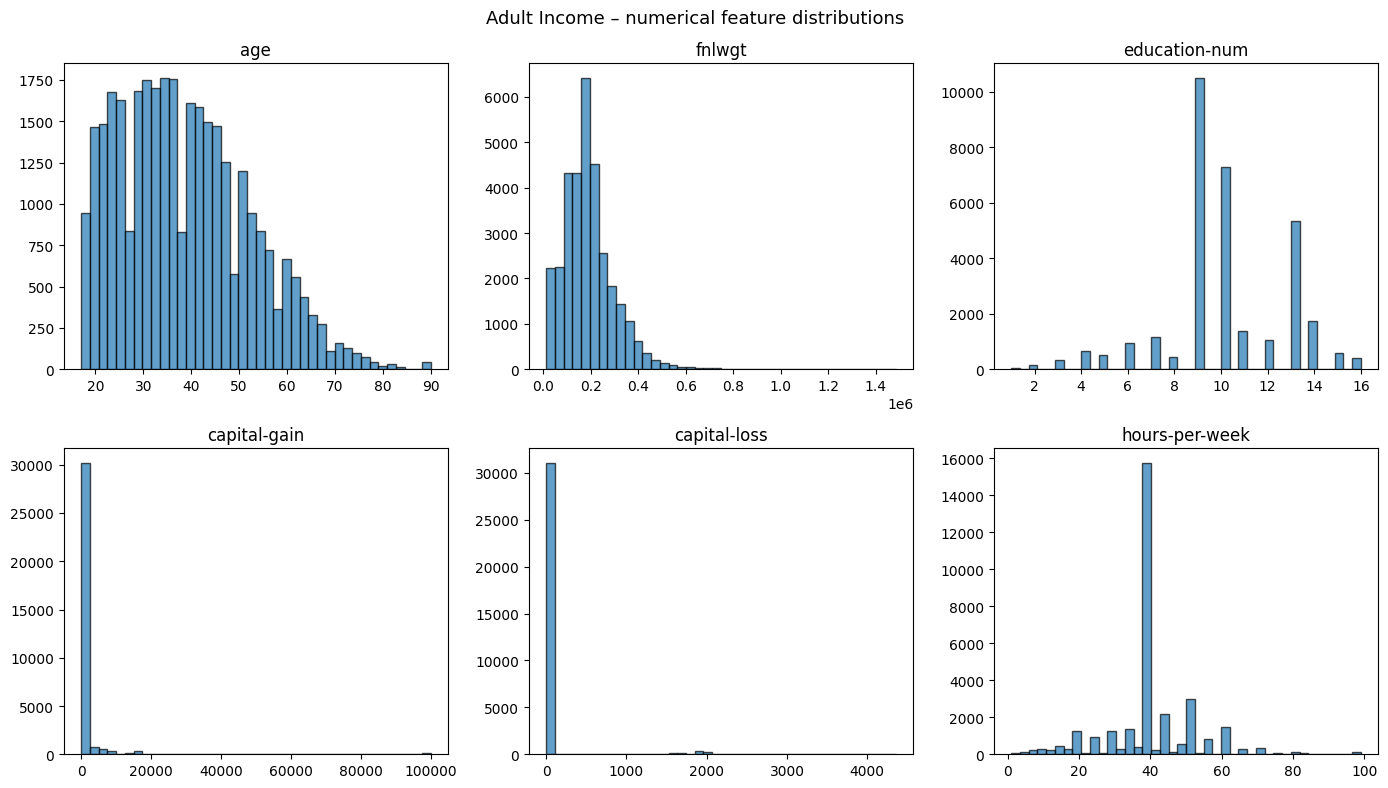

In [7]:
num_cols_eda = [
    'age', 'fnlwgt', 'education-num',
    'capital-gain', 'capital-loss', 'hours-per-week'
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), num_cols_eda):
    ax.hist(X_raw[col].dropna(), bins=40, edgecolor='k', alpha=0.7)
    ax.set_title(col)

plt.suptitle("Adult Income – numerical feature distributions", fontsize=13)
plt.tight_layout()
plt.show()

## Preprocessing

- Define numerical and categorical feature groups.
- Convert the target into binary labels (>50K = 1, otherwise 0).
- Handle missing values by using median imputation for numerical features and "Unknown" for categorical features.
- Create binary indicators for capital gain and capital loss, then apply log transformation to reduce skewness.
- Drop fnlwgt and check that no missing values remain.

In [8]:
# Raw columns
num_cols_raw = [
    'age', 'fnlwgt', 'education-num',
    'capital-gain', 'capital-loss', 'hours-per-week'
]

cat_cols = [
    'workclass', 'education', 'marital-status', 'occupation',
    'relationship', 'race', 'sex', 'native-country'
]

In [9]:
y_series = y_raw.astype(str).str.strip().str.replace('.', '', regex=False)
y = np.where(y_series == '>50K', 1, 0).astype(np.int64)

print(f"Positive rate: {y.mean():.3%}")
print(pd.Series(y).value_counts())

Positive rate: 24.081%
0    24720
1     7841
Name: count, dtype: int64


In [10]:
X_proc = X_raw.copy()

# Replace '?' with NaN in categorical columns
for col in cat_cols:
    X_proc[col] = X_proc[col].astype(str).str.strip().replace('?', np.nan)

# Impute numeric columns with median
for col in num_cols_raw:
    X_proc[col] = X_proc[col].fillna(X_proc[col].median())

# Impute categorical columns with 'Unknown'
for col in cat_cols:
    X_proc[col] = X_proc[col].fillna('Unknown')

# Binary flags before log transform
X_proc['has_capital_gain'] = (X_proc['capital-gain'] > 0).astype(int)
X_proc['has_capital_loss'] = (X_proc['capital-loss'] > 0).astype(int)

# Log transform skewed monetary features
X_proc['capital-gain'] = np.log1p(X_proc['capital-gain'])
X_proc['capital-loss'] = np.log1p(X_proc['capital-loss'])

# Drop survey-weight column
X_proc = X_proc.drop(columns=['fnlwgt'])

print("Missing after preprocessing:", X_proc.isnull().sum().sum())
print(X_proc.head())

Missing after preprocessing: 0
   age workclass     education  education-num marital-status  \
0   90   Unknown       HS-grad              9        Widowed   
1   82   Private       HS-grad              9        Widowed   
2   66   Unknown  Some-college             10        Widowed   
3   54   Private       7th-8th              4       Divorced   
4   41   Private  Some-college             10      Separated   

          occupation   relationship   race     sex  capital-gain  \
0            Unknown  Not-in-family  White  Female           0.0   
1    Exec-managerial  Not-in-family  White  Female           0.0   
2            Unknown      Unmarried  Black  Female           0.0   
3  Machine-op-inspct      Unmarried  White  Female           0.0   
4     Prof-specialty      Own-child  White  Female           0.0   

   capital-loss  hours-per-week native-country  has_capital_gain  \
0      8.379539              40  United-States                 0   
1      8.379539              18  United

In [11]:
# Define final column groups after preprocessing
num_cols_final = [
    'age', 'education-num', 'capital-gain',
    'capital-loss', 'hours-per-week',
    'has_capital_gain', 'has_capital_loss'
]

cat_cols_final = [
    'workclass', 'education', 'marital-status', 'occupation',
    'relationship', 'race', 'sex', 'native-country'
]

## Data Splitting (60 / 20 / 20)

- Split data into training and temporary sets using stratified sampling.
- Further split the temporary set into validation and test sets.
- Ensures consistent class distribution across all splits.

In [12]:
# First split: train vs temp (val + test)
X_train_df, X_temp_df, y_train, y_temp = train_test_split(
    X_proc, y,
    test_size=TEST_SIZE + (1 - TEST_SIZE) * VAL_FRAC,  
    random_state=42,
    stratify=y
)

# Second split: val vs test
X_val_df, X_test_df, y_val, y_test = train_test_split(
    X_temp_df, y_temp,
    test_size=TEST_SIZE / (TEST_SIZE + (1 - TEST_SIZE) * VAL_FRAC),  
    random_state=42,
    stratify=y_temp
)

Classical Model Pipeline
- Apply one-hot encoding to categorical features.
- Align validation and test columns with training data.
- Convert all features to float for consistency.
- Ensures compatibility across classical models.

In [13]:
# Classical models pipeline - logistic regression, random forest, xgboost, lightgbm

X_train_c = pd.get_dummies(X_train_df, drop_first=True)
X_val_c   = pd.get_dummies(X_val_df, drop_first=True)
X_test_c  = pd.get_dummies(X_test_df, drop_first=True)

# Align columns
X_val_c  = X_val_c.reindex(columns=X_train_c.columns, fill_value=0)
X_test_c = X_test_c.reindex(columns=X_train_c.columns, fill_value=0)

# Convert to float for consistency
X_train_c = X_train_c.astype(np.float32)
X_val_c   = X_val_c.astype(np.float32)
X_test_c  = X_test_c.astype(np.float32)

print("Classical shapes:")
print("Train:", X_train_c.shape)
print("Val:  ", X_val_c.shape)
print("Test: ", X_test_c.shape)

Classical shapes:
Train: (19536, 100)
Val:   (6512, 100)
Test:  (6513, 100)


Deep Learning Pipeline
- Encode categorical features using ordinal encoding and shift values for embedding compatibility.
- Standardise numerical features using StandardScaler.
- Convert data into NumPy arrays for model input.
- Prepare feature shapes and cardinalities for ResNet and FT-Transformer.

In [14]:
# Deep learning pipeline ResNet, FT-Transformer

ord_enc = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train_cat = ord_enc.fit_transform(X_train_df[cat_cols_final]).astype(np.int64)
X_val_cat = ord_enc.transform(X_val_df[cat_cols_final]).astype(np.int64)
X_test_cat = ord_enc.transform(X_test_df[cat_cols_final]).astype(np.int64)

# Shift so unknown becomes 0
X_train_cat = X_train_cat + 1
X_val_cat = X_val_cat + 1
X_test_cat = X_test_cat + 1

cat_cardinalities = [len(categories) + 1 for categories in ord_enc.categories_]

scaler_num = StandardScaler()
X_train_num = scaler_num.fit_transform(X_train_df[num_cols_final].astype(np.float32)).astype(np.float32)
X_val_num = scaler_num.transform(X_val_df[num_cols_final].astype(np.float32)).astype(np.float32)
X_test_num = scaler_num.transform(X_test_df[num_cols_final].astype(np.float32)).astype(np.float32)

y_train_np = np.asarray(y_train).astype(np.int64)
y_val_np = np.asarray(y_val).astype(np.int64)
y_test_np = np.asarray(y_test).astype(np.int64)

print("Numeric shapes:")
print("Train:", X_train_num.shape)
print("Val:  ", X_val_num.shape)
print("Test: ", X_test_num.shape)

print("\nCategorical shapes:")
print("Train:", X_train_cat.shape)
print("Val:  ", X_val_cat.shape)
print("Test: ", X_test_cat.shape)

print("\nTarget shapes:")
print("Train:", y_train_np.shape)
print("Val:  ", y_val_np.shape)
print("Test: ", y_test_np.shape)

print("\nCategorical cardinalities:")
print(cat_cardinalities)

Numeric shapes:
Train: (19536, 7)
Val:   (6512, 7)
Test:  (6513, 7)

Categorical shapes:
Train: (19536, 8)
Val:   (6512, 8)
Test:  (6513, 8)

Target shapes:
Train: (19536,)
Val:   (6512,)
Test:  (6513,)

Categorical cardinalities:
[10, 17, 8, 16, 7, 6, 3, 42]


- Verify categorical values are non-negative and within expected ranges.
- Confirm correct data types for numerical, categorical, and target variables.
- Check target values to ensure proper binary encoding.

In [15]:
print("Min categorical value:", X_train_cat.min())
print("Max values by column:", X_train_cat.max(axis=0))
print("Any negative in cat?", (X_train_cat < 0).any())

print("Numeric dtype:", X_train_num.dtype)
print("Categorical dtype:", X_train_cat.dtype)
print("Target dtype:", y_train_np.dtype)
print("Target unique values:", np.unique(y_train_np))

Min categorical value: 1
Max values by column: [ 9 16  7 15  6  5  2 41]
Any negative in cat? False
Numeric dtype: float32
Categorical dtype: int64
Target dtype: int64
Target unique values: [0 1]


## Helper Functions

- Set random seeds for reproducibility across NumPy, PyTorch, and CUDA.
- Define classification metrics: accuracy, AUC, and F1-score.
- Implement generic training and prediction functions for deep learning models with numerical and categorical inputs, including early stopping and optional timing.

In [16]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def compute_classification_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return acc, auc, f1


def train_tabular_model(
    model,
    X_num_tr,
    X_cat_tr,
    y_tr,
    X_num_v,
    X_cat_v,
    y_v,
    n_epochs,
    lr=1e-3,
    n_patience=N_PATIENCE,
    batch_size=N_BATCH_SIZE,
    val_batch_size=N_BATCH_SIZE,
    device_="cpu",
    use_amp=True,
    use_class_weight=False,
    timer=None,
):
    model = model.to(device_)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)

    if use_class_weight:
        pos_weight = float((y_tr == 0).sum()) / float((y_tr == 1).sum())
        criterion = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=device_)
        )
    else:
        criterion = nn.BCEWithLogitsLoss()

    amp_on = use_amp and torch.cuda.is_available() and str(device_).startswith("cuda")
    scaler = torch.amp.GradScaler(device=str(device_), enabled=amp_on)

    # Keep tensors on CPU; move batches to device during training
    X_num_tr_t = torch.as_tensor(X_num_tr, dtype=torch.float32)
    X_cat_tr_t = torch.as_tensor(X_cat_tr, dtype=torch.long) if X_cat_tr is not None else None
    y_tr_t = torch.as_tensor(y_tr, dtype=torch.float32)

    X_num_v_t = torch.as_tensor(X_num_v, dtype=torch.float32)
    X_cat_v_t = torch.as_tensor(X_cat_v, dtype=torch.long) if X_cat_v is not None else None
    y_v_t = torch.as_tensor(y_v, dtype=torch.float32)

    train_losses = []
    val_losses = []
    best_val = float("inf")
    best_state = None
    patience = n_patience
    pat_cnt = 0

    for epoch in range(n_epochs):
        model.train()
        n = len(X_num_tr_t)
        idx = torch.randperm(n)
        ep_loss = 0.0

        for i in range(0, n, batch_size):
            b = idx[i:i + batch_size]

            xn = X_num_tr_t[b].to(device_, non_blocking=True)
            xc = X_cat_tr_t[b].to(device_, non_blocking=True) if X_cat_tr_t is not None else None
            yb = y_tr_t[b].to(device_, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            if timer:
                timer.start("forward")
            with torch.amp.autocast(device_type="cuda", enabled=amp_on):
                out = model(xn, xc).squeeze(-1)
                loss = criterion(out, yb)
            if timer:
                timer.stop("forward")

            if timer:
                timer.start("backward")
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            if timer:
                timer.stop("backward")

            ep_loss += loss.item() * len(b)

        model.eval()
        val_loss_acc = 0.0
        n_v = len(X_num_v_t)

        with torch.no_grad():
            if timer:
                timer.start("validation")

            for j in range(0, n_v, val_batch_size):
                xn_v = X_num_v_t[j:j + val_batch_size].to(device_, non_blocking=True)
                xc_v = (X_cat_v_t[j:j + val_batch_size].to(device_, non_blocking=True)
                    if X_cat_v_t is not None else None)
                yb_v = y_v_t[j:j + val_batch_size].to(device_, non_blocking=True)
                
                with torch.amp.autocast(device_type="cuda", enabled=amp_on):
                    vout = model(xn_v, xc_v).squeeze(-1)
                    val_loss_acc += criterion(vout, yb_v).item() * len(xn_v)

            if timer:
                timer.stop("validation")

        vloss = val_loss_acc / n_v
        train_losses.append(ep_loss / n)
        val_losses.append(vloss)

        if vloss < best_val:
            best_val = vloss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            pat_cnt = 0
        else:
            pat_cnt += 1
            if pat_cnt >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, train_losses, val_losses


def predict_tabular_model(
        model,
        X_num,
        X_cat,
        device_,
        batch_size=N_BATCH_SIZE,
        timer=None,
    ):
    
    model.eval()
    model = model.to(device_)

    X_num_t = torch.as_tensor(X_num, dtype=torch.float32)
    X_cat_t = torch.as_tensor(X_cat, dtype=torch.long) if X_cat is not None else None

    amp_on = torch.cuda.is_available() and str(device_).startswith("cuda")

    logits = []
    probs = []

    with torch.no_grad():
        for i in range(0, len(X_num_t), batch_size):
            xn = X_num_t[i:i + batch_size].to(device_, non_blocking=True)
            xc = (
                X_cat_t[i:i + batch_size].to(device_, non_blocking=True)
                if X_cat_t is not None else None
            )

            if timer:
                timer.start("inference")
            with torch.amp.autocast(device_type="cuda", enabled=amp_on):
                out = model(xn, xc).squeeze(-1)
            if timer:
                timer.stop("inference")

            pr = torch.sigmoid(out)
            logits.append(out.cpu().numpy())
            probs.append(pr.cpu().numpy())

    logits = np.concatenate(logits)
    probs = np.concatenate(probs)
    preds = (probs >= 0.5).astype(int)

    return logits, probs, preds


class PhaseTimer:
    def __init__(self):
        self._totals = {}
        self._counts = {}
        self._start = {}

    def start(self, phase):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        self._start[phase] = time.perf_counter()

    def stop(self, phase):
        if phase not in self._start:
            return
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        elapsed = time.perf_counter() - self._start[phase]
        self._totals[phase] = self._totals.get(phase, 0.0) + elapsed
        self._counts[phase] = self._counts.get(phase, 0) + 1

    def get_total(self, phase):
        return self._totals.get(phase, 0.0)

    def reset(self):
        self._totals.clear()
        self._counts.clear()
        self._start.clear()

    def report(self, label=""):
        total = sum(self._totals.values())
        print(f"\n--- Bottleneck Report {label} ---")
        for k, v in sorted(self._totals.items(), key=lambda x: -x[1]):
            pct = 100 * v / total if total > 0 else 0.0
            avg = 1000 * v / self._counts[k]
            print(f"{k:<20} {v:.3f}s ({pct:.1f}%) avg {avg:.2f} ms")
        print(f"TOTAL: {total:.3f}s\n")

In [17]:
all_results = []
timing_results = []

ft_train_curves = {}

## Model 1: Tabular ResNet

In [19]:
class TabularResNet(nn.Module):
    """RTDL ResNet backbone with learned categorical embeddings."""
    def __init__(
        self,
        n_num_features,
        cat_cardinalities,
        d_embedding=16,
        n_blocks=3,
        d_block=128,
        d_hidden=256,
        dropout1=0.1,
        dropout2=0.0,
    ):
        super().__init__()

        self.has_cat = cat_cardinalities is not None and len(cat_cardinalities) > 0

        if self.has_cat:
            self.cat_embeddings = nn.ModuleList([
                nn.Embedding(cardinality, d_embedding)
                for cardinality in cat_cardinalities
            ])
            cat_dim = len(cat_cardinalities) * d_embedding
        else:
            self.cat_embeddings = None
            cat_dim = 0

        d_in = n_num_features + cat_dim

        self.resnet = _RTDLResNet(
            d_in=d_in,
            d_out=1,
            n_blocks=n_blocks,
            d_block=d_block,
            d_hidden=d_hidden,
            d_hidden_multiplier=None,
            dropout1=dropout1,
            dropout2=dropout2,
        )

    def forward(self, x_num, x_cat=None):
        if self.has_cat and x_cat is not None:
            cat_embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.cat_embeddings)]
            x = torch.cat([x_num] + cat_embs, dim=1)
        else:
            x = x_num
        return self.resnet(x)


def resnet_clf_objective(trial):
    d_embedding = trial.suggest_categorical("d_embedding", [8, 16, 24, 32])
    d_block = trial.suggest_categorical("d_block", [64, 128, 256])
    d_hidden = trial.suggest_categorical("d_hidden", [128, 256, 512])
    n_blocks = trial.suggest_int("n_blocks", 1, 4)
    dropout1 = trial.suggest_float("dropout1", 0.0, 0.5)
    dropout2 = trial.suggest_float("dropout2", 0.0, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)

    set_seed(42)

    model = TabularResNet(
        n_num_features=X_train_num.shape[1],
        cat_cardinalities=cat_cardinalities,
        d_embedding=d_embedding,
        n_blocks=n_blocks,
        d_block=d_block,
        d_hidden=d_hidden,
        dropout1=dropout1,
        dropout2=dropout2,
    )

    model, _, _ = train_tabular_model(
        model=model,
        X_num_tr=X_train_num,
        X_cat_tr=X_train_cat,
        y_tr=y_train_np,
        X_num_v=X_val_num,
        X_cat_v=X_val_cat,
        y_v=y_val_np,
        n_epochs=OPT_EPOCHS,
        lr=lr,
        n_patience=N_PATIENCE,
        batch_size=N_BATCH_SIZE,
        val_batch_size=N_BATCH_SIZE,
        device_=device_,
        use_amp=True,
        use_class_weight=True,
    )

    _, val_probs, _ = predict_tabular_model(
        model=model,
        X_num=X_val_num,
        X_cat=X_val_cat,
        device_=device_
    )

    print (f"Trial {trial.number+1} - ResNet AUC: {roc_auc_score(y_val_np, val_probs):.4f}")
    
    return roc_auc_score(y_val_np, val_probs)

# Tune ResNet
optuna_timer = PhaseTimer()

optuna_timer.start("optuna")
study_resnet = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_resnet.optimize(resnet_clf_objective, n_trials=N_OPTUNA_TRIALS)
optuna_timer.stop("optuna")

optuna_time_resnet = optuna_timer.get_total("optuna")

best_resnet = study_resnet.best_params
print("Trials done:", len(study_resnet.trials))
print("Best ResNet AUC:", study_resnet.best_value)
print("\nBest ResNet params:")
print(best_resnet)


Trial 1 - ResNet AUC: 0.9028
Trial 2 - ResNet AUC: 0.9000
Trial 3 - ResNet AUC: 0.9006
Trial 4 - ResNet AUC: 0.9006
Trial 5 - ResNet AUC: 0.8970
Trial 6 - ResNet AUC: 0.8987
Trial 7 - ResNet AUC: 0.9011
Trial 8 - ResNet AUC: 0.8984
Trial 9 - ResNet AUC: 0.9019
Trial 10 - ResNet AUC: 0.8993
Trial 11 - ResNet AUC: 0.9035
Trial 12 - ResNet AUC: 0.9034
Trial 13 - ResNet AUC: 0.9035
Trial 14 - ResNet AUC: 0.9022
Trial 15 - ResNet AUC: 0.9057
Trial 16 - ResNet AUC: 0.9059
Trial 17 - ResNet AUC: 0.9020
Trial 18 - ResNet AUC: 0.9060
Trial 19 - ResNet AUC: 0.9029
Trial 20 - ResNet AUC: 0.9056
Trials done: 20
Best ResNet AUC: 0.9059549221691103

Best ResNet params:
{'d_embedding': 8, 'd_block': 128, 'd_hidden': 128, 'n_blocks': 3, 'dropout1': 0.1689068175612785, 'dropout2': 0.3895370894390008, 'lr': 0.001220218887094682}


In [20]:
# Train ResNet across seeds
print("\nTraining ResNet across seeds...")

train_timer = PhaseTimer()

best_resnet_auc = -1
resnet_model_best = None
resnet_train_curves = {}

for seed in SEEDS:
    set_seed(seed)

    model = TabularResNet(
        n_num_features=X_train_num.shape[1],
        cat_cardinalities=cat_cardinalities,
        d_embedding=best_resnet["d_embedding"],
        n_blocks=best_resnet["n_blocks"],
        d_block=best_resnet["d_block"],
        d_hidden=best_resnet["d_hidden"],
        dropout1=best_resnet["dropout1"],
        dropout2=best_resnet["dropout2"],
    )

    train_timer.start("train")
    model, train_losses, val_losses = train_tabular_model(
        model=model,
        X_num_tr=X_train_num,
        X_cat_tr=X_train_cat,
        y_tr=y_train_np,
        X_num_v=X_val_num,
        X_cat_v=X_val_cat,
        y_v=y_val_np,
        n_epochs=TR_EPOCHS,
        lr=best_resnet["lr"],
        n_patience=N_PATIENCE,
        batch_size=N_BATCH_SIZE,
        val_batch_size=N_BATCH_SIZE,
        device_=device_,
        use_amp=True,
        use_class_weight=True,
        timer=train_timer,
    )
    train_timer.stop("train")

    resnet_train_curves[seed] = (train_losses, val_losses)

    train_timer.start("inference")
    _, test_probs, test_preds = predict_tabular_model(
        model=model,
        X_num=X_test_num,
        X_cat=X_test_cat,
        device_=device_,
        timer=train_timer,
    )
    train_timer.stop("inference")

    batch_latency = train_timer.get_total("inference")
    per_sample_latency = batch_latency / len(X_test_num)

    acc, auc, f1 = compute_classification_metrics(y_test_np, test_preds, test_probs)

    if auc > best_resnet_auc:
        best_resnet_auc = auc
        resnet_model_best = model

    all_results.append({
        "method": "ResNet",
        "seed": seed,
        "accuracy": acc,
        "auc": auc,
        "f1": f1,
    })

    print(f"Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, F1={f1:.4f}, "
          f"batch latency={batch_latency:.2f}s, per-sample latency={per_sample_latency:.3g}s")


Training ResNet across seeds...
Seed 42: Acc=0.8021, AUC=0.9061, F1=0.6759, batch latency=0.01s, per-sample latency=1.47e-06s
Seed 123: Acc=0.8010, AUC=0.9028, F1=0.6754, batch latency=0.02s, per-sample latency=2.88e-06s
Seed 456: Acc=0.7952, AUC=0.9049, F1=0.6701, batch latency=0.03s, per-sample latency=4.96e-06s


In [21]:
# Estimate the in-memory size of the trained TabularResNet model
buffer = io.BytesIO()
torch.save(model.state_dict(), buffer)
size_mb = len(buffer.getvalue()) / (1024 * 1024)
print(f"Model size in memory: {size_mb:.2f} MB")

# Compute the total number of parameters as a measure for model size
size_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {size_params:,}")

Model size in memory: 0.44 MB
Total parameters: 110,313


In [22]:

timing_results.append({
    "method": "ResNet",
    "optuna_time": optuna_time_resnet,
    "train_time": train_timer.get_total("train"),
    "inference_time": train_timer.get_total("inference"),
})

print("\nTrain/Inference timer report:")
train_timer.report("ResNet")

print("\nOptuna timer report:")
optuna_timer.report("ResNet Optuna")


Train/Inference timer report:

--- Bottleneck Report ResNet ---
train                9.397s (52.1%) avg 3132.27 ms
backward             5.112s (28.4%) avg 3.55 ms
forward              2.740s (15.2%) avg 1.90 ms
validation           0.739s (4.1%) avg 10.26 ms
inference            0.032s (0.2%) avg 1.35 ms
TOTAL: 18.021s


Optuna timer report:

--- Bottleneck Report ResNet Optuna ---
optuna               77.962s (100.0%) avg 77962.16 ms
TOTAL: 77.962s



## Model 2: FT-Transformer

In [23]:
n_num_ft = X_train_num.shape[1]


def ft_clf_objective(trial):
    d_block = trial.suggest_categorical("d_block", [64, 128, 192, 256])
    n_blocks = trial.suggest_int("n_blocks", 1, 3)
    attn_heads= trial.suggest_categorical('attention_n_heads',  [2, 4])
    ffn_mult  = trial.suggest_float('ffn_d_hidden_multiplier', 1.0, 1.5)
    attention_dropout = trial.suggest_float("attention_dropout", 0.0, 0.3)
    ffn_dropout = trial.suggest_float("ffn_dropout", 0.0, 0.3)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    
    set_seed(42)

    model = FTTransformer(
        n_cont_features=n_num_ft,
        cat_cardinalities=cat_cardinalities,
        n_blocks=n_blocks,
        d_block=d_block,
        attention_n_heads=attn_heads,
        attention_dropout=attention_dropout,
        ffn_d_hidden_multiplier=ffn_mult,
        ffn_dropout=ffn_dropout,
        residual_dropout=0.0,
        d_out=1,
    )

    model, _, _ = train_tabular_model(
        model=model,
        X_num_tr=X_train_num,
        X_cat_tr=X_train_cat,
        y_tr=y_train_np,
        X_num_v=X_val_num,
        X_cat_v=X_val_cat,
        y_v=y_val_np,
        n_epochs=OPT_EPOCHS,
        lr=lr,
        n_patience=N_PATIENCE,
        batch_size=N_BATCH_SIZE,
        val_batch_size=N_BATCH_SIZE,
        device_=device_,
        use_amp=True,
        use_class_weight=True,
    )

    _, val_probs, _ = predict_tabular_model(
        model=model,
        X_num=X_val_num,
        X_cat=X_val_cat,
        device_=device_,
        batch_size=N_BATCH_SIZE,
    )

    # Log trial details
    print (f"Trial {trial.number+1} : ROC-AUC={roc_auc_score(y_val_np, val_probs):.4f}")

    return roc_auc_score(y_val_np, val_probs)


# Tune FT-Transformer
optuna_timer = PhaseTimer()

optuna_timer.start("optuna")
study_ft = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_ft.optimize(ft_clf_objective, n_trials=N_OPTUNA_TRIALS)
optuna_timer.stop("optuna")

optuna_time_ft = optuna_timer.get_total("optuna")

best_ft = study_ft.best_params
print("Trials done:", len(study_ft.trials))
print("Best FT-Transformer AUC:", study_ft.best_value)
print("\nBest FT-Transformer params:")
print(best_ft)

Trial 1 : ROC-AUC=0.8999
Trial 2 : ROC-AUC=0.9005
Trial 3 : ROC-AUC=0.9011
Trial 4 : ROC-AUC=0.9072
Trial 5 : ROC-AUC=0.9074
Trial 6 : ROC-AUC=0.9082
Trial 7 : ROC-AUC=0.9043
Trial 8 : ROC-AUC=0.9015
Trial 9 : ROC-AUC=0.9058
Trial 10 : ROC-AUC=0.9068
Trial 11 : ROC-AUC=0.9012
Trial 12 : ROC-AUC=0.9080
Trial 13 : ROC-AUC=0.9062
Trial 14 : ROC-AUC=0.9008
Trial 15 : ROC-AUC=0.9067
Trial 16 : ROC-AUC=0.9052
Trial 17 : ROC-AUC=0.9053
Trial 18 : ROC-AUC=0.9067
Trial 19 : ROC-AUC=0.9063
Trial 20 : ROC-AUC=0.9020
Trials done: 20
Best FT-Transformer AUC: 0.9081671996772009

Best FT-Transformer params:
{'d_block': 64, 'n_blocks': 1, 'attention_n_heads': 2, 'ffn_d_hidden_multiplier': 1.4143687545759647, 'attention_dropout': 0.10702599800807679, 'ffn_dropout': 0.08428035290621423, 'lr': 0.0008356499023325525}


In [24]:
# Train FT-Transformer across seeds
print("\nTraining FT-Transformer across seeds...")

train_timer = PhaseTimer()

ft_train_curves = {}
best_ft_auc = -1
ft_model_best = None

for seed in SEEDS:
    set_seed(seed)

    model = FTTransformer(
        n_cont_features=n_num_ft,
        cat_cardinalities=cat_cardinalities,
        d_out=1,
        n_blocks=best_ft["n_blocks"],
        d_block=best_ft["d_block"],
        attention_n_heads=best_ft["attention_n_heads"],
        attention_dropout=best_ft["attention_dropout"],
        ffn_d_hidden_multiplier=best_ft["ffn_d_hidden_multiplier"],
        ffn_dropout=best_ft["ffn_dropout"],
        residual_dropout=0.0,
    )

    train_timer.start("train")
    model, train_losses, val_losses = train_tabular_model(
        model=model,
        X_num_tr=X_train_num,
        X_cat_tr=X_train_cat,
        y_tr=y_train_np,
        X_num_v=X_val_num,
        X_cat_v=X_val_cat,
        y_v=y_val_np,
        n_epochs=TR_EPOCHS,
        lr=best_ft["lr"],
        n_patience=N_PATIENCE,
        device_=device_,
        use_amp=True,
        use_class_weight=True,
        timer=train_timer,
    )
    train_timer.stop("train")

    ft_train_curves[seed] = (train_losses, val_losses)

    train_timer.start("inference")
    _, test_probs, test_preds = predict_tabular_model(
        model=model,
        X_num=X_test_num,
        X_cat=X_test_cat,
        device_=device_,
        batch_size=N_BATCH_SIZE,
        timer=train_timer,
    )
    train_timer.stop("inference")

    batch_latency = train_timer.get_total("inference")
    per_sample_latency = batch_latency / len(X_test_num)

    acc, auc, f1 = compute_classification_metrics(y_test_np, test_preds, test_probs)

    if auc > best_ft_auc:
        best_ft_auc = auc
        ft_model_best = model

    all_results.append({
        "method": "FT-Transformer",
        "seed": seed,
        "accuracy": acc,
        "auc": auc,
        "f1": f1,
    })

    print(f"Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, F1={f1:.4f}, batch latency={batch_latency:.2f}s, per-sample latency={per_sample_latency:.3g}s")

ft_model_last = model # Store the last trained model for feature importance 


Training FT-Transformer across seeds...
Seed 42: Acc=0.8111, AUC=0.9088, F1=0.6815, batch latency=0.01s, per-sample latency=1.48e-06s
Seed 123: Acc=0.7998, AUC=0.9084, F1=0.6747, batch latency=0.02s, per-sample latency=2.92e-06s
Seed 456: Acc=0.7909, AUC=0.9103, F1=0.6710, batch latency=0.03s, per-sample latency=5.31e-06s


In [25]:
# Estimate the in-memory size of the trained FT-Transformer model
buffer = io.BytesIO()
torch.save(model.state_dict(), buffer)
size_mb = len(buffer.getvalue()) / (1024 * 1024)
print(f"Model size in memory: {size_mb:.2f} MB")

# Compute the total number of parameters as a measure for model size
size_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {size_params:,}")

Model size in memory: 0.17 MB
Total parameters: 42,933


In [26]:
timing_results.append({
    "method": "FT-Transformer",
    "optuna_time": optuna_time_ft,
    "train_time": train_timer.get_total("train"),
    "inference_time": train_timer.get_total("inference"),
})

print("\nTrain/Inference timer report:")
train_timer.report("FT-Transformer")

print("\nOptuna timer report:")
optuna_timer.report("FT-Transformer Optuna")


Train/Inference timer report:

--- Bottleneck Report FT-Transformer ---
train                22.660s (51.9%) avg 7553.22 ms
backward             12.987s (29.8%) avg 4.08 ms
forward              6.194s (14.2%) avg 1.95 ms
validation           1.757s (4.0%) avg 11.05 ms
inference            0.035s (0.1%) avg 1.44 ms
TOTAL: 43.633s


Optuna timer report:

--- Bottleneck Report FT-Transformer Optuna ---
optuna               159.625s (100.0%) avg 159625.39 ms
TOTAL: 159.625s



## Model 3: XGBoost

In [27]:
# Class imbalance ratio
scale_pos_weight_base = (y_train_np == 0).sum() / (y_train_np == 1).sum()
print("Base scale_pos_weight:", scale_pos_weight_base)


def xgb_clf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float(
            'scale_pos_weight',
            max(1.0, scale_pos_weight_base * 0.7),
            scale_pos_weight_base * 1.3
        ),
        'random_state': 42,
        'eval_metric': 'auc',
        'verbosity': 0,
        'tree_method': 'hist',
        'n_jobs': -1
    }

    set_seed(42)

    model = xgb.XGBClassifier(**params)
    model.fit(X_train_c, y_train_np)

    val_probs = model.predict_proba(X_val_c)[:, 1]
    return roc_auc_score(y_val_np, val_probs)


# Tune XGBoost

optuna_timer = PhaseTimer()

optuna_timer.start("optuna")
study_xgb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_xgb.optimize(xgb_clf_objective, n_trials=N_OPTUNA_TRIALS)
optuna_timer.stop("optuna")

optuna_time_xgb = optuna_timer.get_total("optuna")

best_xgb = study_xgb.best_params
print("Trials done:", len(study_xgb.trials))
print("Best XGBoost AUC:", study_xgb.best_value)
print("\nBest XGBoost params:")
print(best_xgb)


Base scale_pos_weight: 3.1530612244897958
Trials done: 20
Best XGBoost AUC: 0.9207113936290535

Best XGBoost params:
{'n_estimators': 452, 'max_depth': 5, 'learning_rate': 0.03416349944524313, 'subsample': 0.7799465042658286, 'colsample_bytree': 0.7488645104787093, 'min_child_weight': 1, 'gamma': 4.2942775256585985, 'reg_alpha': 1.2722974438529106e-08, 'reg_lambda': 0.013425608609788007, 'scale_pos_weight': 3.6728204762909913}


In [28]:
# Train XGBoost across seeds

print("\nTraining XGBoost across seeds...")

train_timer = PhaseTimer()

best_xgb_auc = -1
xgb_model_best = None

for seed in SEEDS:
    set_seed(seed)

    model = xgb.XGBClassifier(
        **best_xgb,
        random_state=seed,
        eval_metric="auc",
        verbosity=0,
        tree_method="hist",
        n_jobs=-1,
    )

    train_timer.start("train")
    model.fit(X_train_c, y_train_np)
    train_timer.stop("train")

    train_timer.start("inference")
    test_preds = model.predict(X_test_c)
    test_probs = model.predict_proba(X_test_c)[:, 1]
    train_timer.stop("inference")

    batch_latency = train_timer.get_total("inference")
    per_sample_latency = batch_latency / len(X_test_c)

    acc, auc, f1 = compute_classification_metrics(y_test_np, test_preds, test_probs)

    if auc > best_xgb_auc:
        best_xgb_auc = auc
        xgb_model_best = model

    all_results.append({
        "method": "XGBoost",
        "seed": seed,
        "accuracy": acc,
        "auc": auc,
        "f1": f1,
    })

    xgb_model_last = model # Store the last trained model for feature importance
    print(f"Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, F1={f1:.4f}")


Training XGBoost across seeds...
Seed 42: Acc=0.8217, AUC=0.9256, F1=0.7024
Seed 123: Acc=0.8240, AUC=0.9257, F1=0.7051
Seed 456: Acc=0.8227, AUC=0.9257, F1=0.7033


In [29]:
# Estimate the in-memory size of the trained XGBoost model
booster = xgb_model_last.get_booster()
raw_bytes = booster.save_raw()   # returns bytes
size_mb = len(raw_bytes) / (1024 * 1024)
print(f"XGBoost model size in memory: {size_mb:.2f} MB")

# Compute the total number of nodes across all trees as a measure for model size/complexity
df_nodes_xgb = booster.trees_to_dataframe()
print("Total nodes:", len(df_nodes_xgb))

XGBoost model size in memory: 0.73 MB
Total nodes: 13514


In [30]:
timing_results.append({
    "method": "XGBoost",
    "optuna_time": optuna_time_xgb,
    "train_time": train_timer.get_total("train"),
    "inference_time": train_timer.get_total("inference"),
})

print("\nTrain/Inference timer report:")
train_timer.report("XGBoost")
print("\nOptuna timer report:")
optuna_timer.report("XGBoost Optuna")



Train/Inference timer report:

--- Bottleneck Report XGBoost ---
train                1.316s (96.9%) avg 438.69 ms
inference            0.042s (3.1%) avg 13.93 ms
TOTAL: 1.358s


Optuna timer report:

--- Bottleneck Report XGBoost Optuna ---
optuna               7.563s (100.0%) avg 7562.91 ms
TOTAL: 7.563s



## Model 4: LightGBM

In [31]:
# Class imbalance ratio
scale_pos_weight_base = (y_train_np == 0).sum() / (y_train_np == 1).sum()
print("Base scale_pos_weight:", scale_pos_weight_base)


def lgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight",
            max(1.0, scale_pos_weight_base * 0.7),
            scale_pos_weight_base * 1.3
        ),
        "objective": "binary",
        "metric": "auc",
        "random_state": 42,
        "verbosity": -1,
        "n_jobs": -1
    }

    set_seed(42)

    model = lgb.LGBMClassifier(**params)
    model.fit(X_train_c, y_train_np)

    val_probs = model.predict_proba(X_val_c)[:, 1]
    return roc_auc_score(y_val_np, val_probs)


# Tune LightGBM
optuna_timer = PhaseTimer()

optuna_timer.start("optuna")
study_lgb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_lgb.optimize(lgb_objective, n_trials=N_OPTUNA_TRIALS)
optuna_timer.stop("optuna")

optuna_time_lgb = optuna_timer.get_total("optuna")

best_lgb = study_lgb.best_params
print("Trials done:", len(study_lgb.trials))
print("Best LightGBM AUC:", study_lgb.best_value)
print("\nBest LightGBM params:")
print(best_lgb)


Base scale_pos_weight: 3.1530612244897958
Trials done: 20
Best LightGBM AUC: 0.9215060720890298

Best LightGBM params:
{'n_estimators': 499, 'num_leaves': 21, 'learning_rate': 0.0262209763647716, 'subsample': 0.7482501209054793, 'colsample_bytree': 0.8142497056141959, 'min_child_samples': 34, 'reg_alpha': 0.055108905097137055, 'reg_lambda': 2.9449142182045547, 'scale_pos_weight': 2.2162166806380137}


In [32]:
# Train LightGBM across seeds
print("\nTraining LightGBM across seeds...")

train_timer = PhaseTimer()

best_lgb_auc = -1
lgb_model_best = None

for seed in SEEDS:
    set_seed(seed)

    model = lgb.LGBMClassifier(
        **best_lgb,
        objective="binary",
        metric="auc",
        random_state=seed,
        verbosity=-1,
        n_jobs=1,
    )

    train_timer.start("train")
    model.fit(X_train_c, y_train_np)
    train_timer.stop("train")

    train_timer.start("inference")
    test_preds = model.predict(X_test_c)
    test_probs = model.predict_proba(X_test_c)[:, 1]
    train_timer.stop("inference")

    batch_latency = train_timer.get_total("inference")
    per_sample_latency = batch_latency / len(X_test_c)

    acc, auc, f1 = compute_classification_metrics(y_test_np, test_preds, test_probs)

    if auc > best_lgb_auc:
        best_lgb_auc = auc
        lgb_model_best = model

    all_results.append({
        "method": "LightGBM",
        "seed": seed,
        "accuracy": acc,
        "auc": auc,
        "f1": f1,
    })

    lgb_model_last = model # Store the last trained model for feature importance
    print(f"Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, F1={f1:.4f}, batch latency={batch_latency:.2f}s, per-sample latency={per_sample_latency:.3g}s")


Training LightGBM across seeds...
Seed 42: Acc=0.8500, AUC=0.9261, F1=0.7236, batch latency=0.29s, per-sample latency=4.44e-05s
Seed 123: Acc=0.8481, AUC=0.9258, F1=0.7212, batch latency=0.57s, per-sample latency=8.7e-05s
Seed 456: Acc=0.8488, AUC=0.9256, F1=0.7220, batch latency=0.85s, per-sample latency=0.00013s


In [33]:
# Save the last trained LightGBM model and print its size
model_str = lgb_model_last.booster_.model_to_string()
size_mb = len(model_str.encode('utf-8')) / (1024 * 1024)
print(f"LightGBM model size in memory: {size_mb:.2f} MB")

# Get the total number of nodes across all trees
df_trees_lgb = lgb_model_last.booster_.trees_to_dataframe()
total_nodes = len(df_trees_lgb)
print(f"Total nodes in LightGBM model: {total_nodes}")

LightGBM model size in memory: 1.16 MB
Total nodes in LightGBM model: 20459


In [34]:
timing_results.append({
    "method": "LightGBM",
    "optuna_time": optuna_time_lgb,
    "train_time": train_timer.get_total("train"),
    "inference_time": train_timer.get_total("inference"),
})

print("\nTrain/Inference timer report:")
train_timer.report("LightGBM")

print("\nOptuna timer report:")
optuna_timer.report("LightGBM Optuna")


Train/Inference timer report:

--- Bottleneck Report LightGBM ---
train                1.603s (65.5%) avg 534.35 ms
inference            0.845s (34.5%) avg 281.77 ms
TOTAL: 2.448s


Optuna timer report:

--- Bottleneck Report LightGBM Optuna ---
optuna               10.507s (100.0%) avg 10507.24 ms
TOTAL: 10.507s



## Model 5: Random Forest

In [35]:
def rf_clf_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample", None]),
        "random_state": 42,
        "n_jobs": -1,
    }

    set_seed(42)

    model = RandomForestClassifier(**params)
    model.fit(X_train_c, y_train_np)

    val_probs = model.predict_proba(X_val_c)[:, 1]
    return roc_auc_score(y_val_np, val_probs)


# Tune Random Forest
optuna_timer = PhaseTimer()

optuna_timer.start("optuna")
study_rf = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_rf.optimize(rf_clf_objective, n_trials=N_OPTUNA_TRIALS)
optuna_timer.stop("optuna")

optuna_time_rf = optuna_timer.get_total("optuna")

best_rf = study_rf.best_params
print("Trials done:", len(study_rf.trials))
print("Best RF AUC:", study_rf.best_value)
print("\nBest RF params:")
print(best_rf)

Trials done: 20
Best RF AUC: 0.9100330590367216

Best RF params:
{'n_estimators': 352, 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': None, 'class_weight': None}


In [36]:
# Train Random Forest across seeds

print("\nTraining Random Forest across seeds...")

train_timer = PhaseTimer()

best_rf_auc = -1
rf_model_best = None

for seed in SEEDS:
    set_seed(seed)

    model = RandomForestClassifier(
        **best_rf,
        random_state=seed,
        n_jobs=-1,
    )

    train_timer.start("train")
    model.fit(X_train_c, y_train_np)
    train_timer.stop("train")

    train_timer.start("inference")
    test_preds = model.predict(X_test_c)
    test_probs = model.predict_proba(X_test_c)[:, 1]
    train_timer.stop("inference")

    batch_latency = train_timer.get_total("inference")
    per_sample_latency = batch_latency / len(X_test_c)

    acc, auc, f1 = compute_classification_metrics(y_test_np, test_preds, test_probs)

    if auc > best_rf_auc:
        best_rf_auc = auc
        rf_model_best = model

    all_results.append({
        "method": "RandomForest",
        "seed": seed,
        "accuracy": acc,
        "auc": auc,
        "f1": f1,
    })

    rf_model_last = model # Store the last trained model for feature importance
    print(f"Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, F1={f1:.4f}, batch latency={batch_latency:.2f}s, per-sample latency={per_sample_latency:.3g}s")


Training Random Forest across seeds...
Seed 42: Acc=0.8615, AUC=0.9160, F1=0.6826, batch latency=0.13s, per-sample latency=1.94e-05s
Seed 123: Acc=0.8626, AUC=0.9162, F1=0.6854, batch latency=0.28s, per-sample latency=4.36e-05s
Seed 456: Acc=0.8637, AUC=0.9153, F1=0.6882, batch latency=0.44s, per-sample latency=6.76e-05s


In [37]:
# Save the last trained Random Forest model and print its size
raw_bytes = pickle.dumps(rf_model_last)
size_mb = len(raw_bytes) / (1024 * 1024)
print(f"Random Forest model size in memory: {size_mb:.2f} MB")

# Get total number of nodes across all trees
total_nodes = sum(estimator.tree_.node_count for estimator in rf_model_last.estimators_)
print(f"Total nodes in Random Forest model: {total_nodes}")

Random Forest model size in memory: 23.14 MB
Total nodes in Random Forest model: 301880


In [38]:
timing_results.append({
    "method": "RandomForest",
    "optuna_time": optuna_time_rf,
    "train_time": train_timer.get_total("train"),
    "inference_time": train_timer.get_total("inference"),
})

print("\nTrain/Inference timer report:")
train_timer.report("Random Forest")

print("\nOptuna timer report:")
optuna_timer.report("Random Forest Optuna")


Train/Inference timer report:

--- Bottleneck Report Random Forest ---
train                5.552s (92.6%) avg 1850.57 ms
inference            0.441s (7.4%) avg 146.85 ms
TOTAL: 5.992s


Optuna timer report:

--- Bottleneck Report Random Forest Optuna ---
optuna               30.029s (100.0%) avg 30029.40 ms
TOTAL: 30.029s



## Model 6: Logistic Regression

In [39]:
def lr_objective(trial):
    params = {
        "C": trial.suggest_float("C", 0.01, 10.0, log=True),
        "penalty": "l2",
        "solver": "liblinear",
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", None]),
        "max_iter": 1000,
        "random_state": 42,
    }

    set_seed(42)

    model = LogisticRegression(**params)
    model.fit(X_train_c, y_train_np)

    val_probs = model.predict_proba(X_val_c)[:, 1]
    return roc_auc_score(y_val_np, val_probs)

# Tune Logistic Regression

optuna_timer = PhaseTimer()

optuna_timer.start("optuna")
study_lr = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_lr.optimize(lr_objective, n_trials=N_OPTUNA_TRIALS)
optuna_timer.stop("optuna")

optuna_time_lr = optuna_timer.get_total("optuna")

best_lr = study_lr.best_params
print("Best Logistic Regression AUC:", study_lr.best_value)
print("\nBest Logistic Regression params:")
print(best_lr)


Best Logistic Regression AUC: 0.903986640165775

Best Logistic Regression params:
{'C': 9.392592363665077, 'class_weight': 'balanced'}


In [40]:
# Train Logistic Regression across seeds

print("\nTraining Logistic Regression across seeds...")

train_timer = PhaseTimer()

for seed in SEEDS:
    set_seed(seed)

    model = LogisticRegression(
        C=best_lr["C"],
        penalty="l2",
        solver="liblinear",
        class_weight=best_lr["class_weight"],
        max_iter=1000,
        random_state=seed,
    )

    train_timer.start("train")
    model.fit(X_train_c, y_train_np)
    train_timer.stop("train")

    # --- Threshold tuning on validation ---
    val_prob = model.predict_proba(X_val_c)[:, 1]
    thresholds = np.linspace(0.01, 0.99, 99)
    f1_scores = [f1_score(y_val_np, (val_prob >= t).astype(int)) for t in thresholds]
    best_t = thresholds[np.argmax(f1_scores)]

    train_timer.start("inference")
    test_preds = model.predict(X_test_c)
    test_probs = model.predict_proba(X_test_c)[:, 1]
    train_timer.stop("inference")

    batch_latency = train_timer.get_total("inference")
    per_sample_latency = batch_latency / len(X_test_c)

    acc, auc, f1 = compute_classification_metrics(y_test_np, test_preds, test_probs)

    all_results.append({
        "method": "LogisticRegression",
        "seed": seed,
        "accuracy": acc,
        "auc": auc,
        "f1": f1,
    })

    lr_model_last = model # Store the last trained model for feature importance
    print(f"Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, F1={f1:.4f}, batch latency={batch_latency:.2f}s, per-sample latency={per_sample_latency:.3g}s")


Training Logistic Regression across seeds...
Seed 42: Acc=0.8067, AUC=0.9052, F1=0.6758, batch latency=0.01s, per-sample latency=9.05e-07s
Seed 123: Acc=0.8067, AUC=0.9052, F1=0.6758, batch latency=0.01s, per-sample latency=1.84e-06s
Seed 456: Acc=0.8067, AUC=0.9052, F1=0.6758, batch latency=0.02s, per-sample latency=2.91e-06s


In [41]:
# Save the last trained Logistic Regression model and print its size
raw_bytes = pickle.dumps(lr_model_last)
size_mb = len(raw_bytes) / (1024 * 1024)
print(f"Logistic Regression model size in memory: {size_mb:.2f} MB")

# Get number of parameters (coefficients + intercept)
num_params = lr_model_last.coef_.size + lr_model_last.intercept_.size
print(f"Total parameters in Logistic Regression model: {num_params:,}")

Logistic Regression model size in memory: 0.00 MB
Total parameters in Logistic Regression model: 101


In [42]:
timing_results.append({
    "method": "LogisticRegression",
    "optuna_time": optuna_time_lr,
    "train_time": train_timer.get_total("train"),
    "inference_time": train_timer.get_total("inference"),
})

print("\nTrain/Inference timer report:")
train_timer.report("Logistic Regression")

print("\nOptuna timer report:")
optuna_timer.report("Logistic Regression Optuna")


Train/Inference timer report:

--- Bottleneck Report Logistic Regression ---
train                0.577s (96.8%) avg 192.41 ms
inference            0.019s (3.2%) avg 6.33 ms
TOTAL: 0.596s


Optuna timer report:

--- Bottleneck Report Logistic Regression Optuna ---
optuna               2.717s (100.0%) avg 2717.15 ms
TOTAL: 2.717s



## Results

In [43]:
# Final performance summary

df_res = pd.DataFrame(all_results)

summary = df_res.groupby("method").agg(
    acc_mean=("accuracy", "mean"),
    acc_std=("accuracy", "std"),
    auc_mean=("auc", "mean"),
    auc_std=("auc", "std"),
    f1_mean=("f1", "mean"),
    f1_std=("f1", "std"),
)

summary = summary.fillna(0)

summary["Accuracy"] = (
    summary["acc_mean"].map("{:.4f}".format) + " ± " + summary["acc_std"].map("{:.4f}".format)
)
summary["AUC-ROC"] = (
    summary["auc_mean"].map("{:.4f}".format) + " ± " + summary["auc_std"].map("{:.4f}".format)
)
summary["F1"] = (
    summary["f1_mean"].map("{:.4f}".format) + " ± " + summary["f1_std"].map("{:.4f}".format)
)

summary_sorted = summary.sort_values(by="auc_mean", ascending=False)
final_table = summary_sorted[["Accuracy", "AUC-ROC", "F1"]]

print("\nFinal Model Comparison:")
print(final_table)



Final Model Comparison:
                           Accuracy          AUC-ROC               F1
method                                                               
LightGBM            0.8490 ± 0.0009  0.9258 ± 0.0003  0.7223 ± 0.0012
XGBoost             0.8228 ± 0.0012  0.9257 ± 0.0000  0.7036 ± 0.0014
RandomForest        0.8626 ± 0.0011  0.9158 ± 0.0005  0.6854 ± 0.0028
FT-Transformer      0.8006 ± 0.0102  0.9091 ± 0.0010  0.6757 ± 0.0053
LogisticRegression  0.8067 ± 0.0000  0.9052 ± 0.0000  0.6758 ± 0.0000
ResNet              0.7994 ± 0.0037  0.9046 ± 0.0017  0.6738 ± 0.0032


In [44]:
# Timing summary

df_time_summary = pd.DataFrame(timing_results).fillna(0)

n_test = len(y_test_np)
df_time_summary["Latency (ms/sample)"] = (
    df_time_summary["inference_time"] / n_test * 1000
).round(4)

df_time_summary["Optuna (s)"] = df_time_summary["optuna_time"].round(2)
df_time_summary["Train (s)"] = df_time_summary["train_time"].round(2)
df_time_summary["Inference (s)"] = df_time_summary["inference_time"].round(4)

df_time_display = df_time_summary[
    ["method", "Optuna (s)", "Train (s)", "Inference (s)", "Latency (ms/sample)"]
].sort_values(by="Train (s)")

print("\nTiming Summary:")
print(df_time_display)




Timing Summary:
               method  Optuna (s)  Train (s)  Inference (s)  \
5  LogisticRegression        2.72       0.58         0.0190   
2             XGBoost        7.56       1.32         0.0418   
3            LightGBM       10.51       1.60         0.8453   
4        RandomForest       30.03       5.55         0.4405   
0              ResNet       77.96       9.40         0.0323   
1      FT-Transformer      159.63      22.66         0.0346   

   Latency (ms/sample)  
5               0.0029  
2               0.0064  
3               0.1298  
4               0.0676  
0               0.0050  
1               0.0053  


## Visualizations

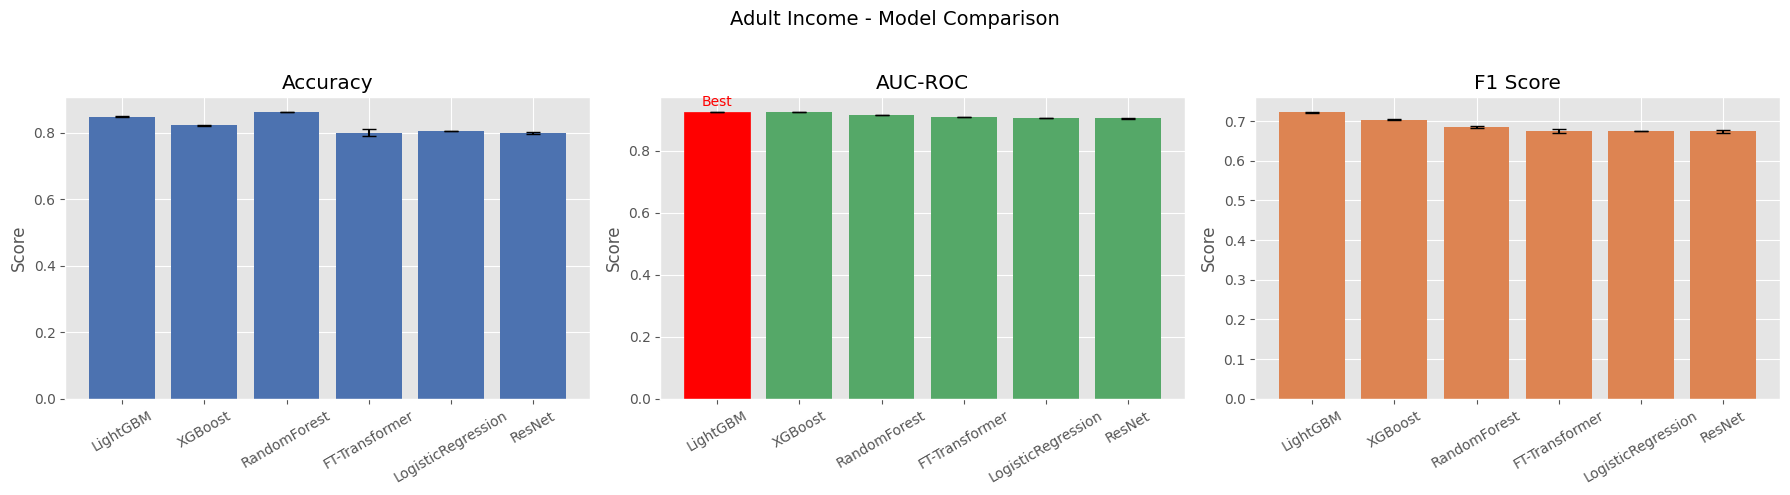

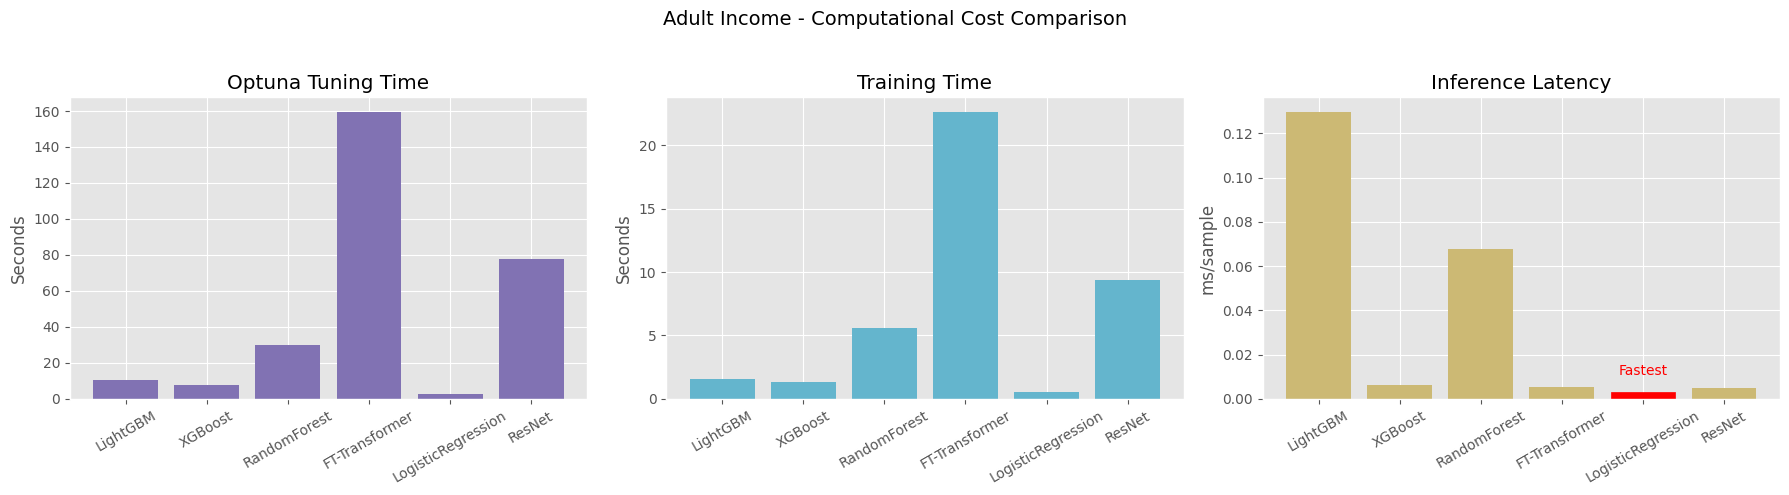

In [45]:
# Plot settings
methods = [
    "LightGBM", "XGBoost", "RandomForest",
    "FT-Transformer", "LogisticRegression", "ResNet"
]

plt.style.use("ggplot")

# Performance plot
methods_perf = [m for m in methods if m in summary.index]
summary_plot = summary.loc[methods_perf]

color_acc = "#4C72B0"
color_auc = "#55A868"
color_f1  = "#DD8452"

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
axes[0].bar(
    summary_plot.index,
    summary_plot["acc_mean"],
    yerr=summary_plot["acc_std"],
    capsize=5,
    color=color_acc
)
axes[0].set_title("Accuracy")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis="x", rotation=30)

# AUC
bars_auc = axes[1].bar(
    summary_plot.index,
    summary_plot["auc_mean"],
    yerr=summary_plot["auc_std"],
    capsize=5,
    color=color_auc
)
axes[1].set_title("AUC-ROC")
axes[1].set_ylabel("Score")
axes[1].tick_params(axis="x", rotation=30)

best_idx = summary_plot["auc_mean"].idxmax()
best_pos = summary_plot.index.get_loc(best_idx)
bars_auc[best_pos].set_color("red")

offset = 0.01 * summary_plot["auc_mean"].max()
axes[1].text(
    best_pos,
    summary_plot.loc[best_idx, "auc_mean"] + offset,
    "Best",
    ha="center",
    va="bottom",
    color="red",
    fontsize=10
)

# F1
axes[2].bar(
    summary_plot.index,
    summary_plot["f1_mean"],
    yerr=summary_plot["f1_std"],
    capsize=5,
    color=color_f1
)
axes[2].set_title("F1 Score")
axes[2].set_ylabel("Score")
axes[2].tick_params(axis="x", rotation=30)

fig.suptitle("Adult Income - Model Comparison", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Computational cost plot
methods_time = [m for m in methods if m in df_time_summary["method"].values]
df_time_plot = (
    df_time_summary.set_index("method")
    .loc[methods_time]
    .reset_index()
)

color_optuna = "#8172B3"
color_train = "#64B5CD"
color_latency = "#CCB974"

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Optuna tuning time
axes[0].bar(
    df_time_plot["method"],
    df_time_plot["optuna_time"],
    color=color_optuna
)
axes[0].set_title("Optuna Tuning Time")
axes[0].set_ylabel("Seconds")
axes[0].tick_params(axis="x", rotation=30)

# Training time
axes[1].bar(
    df_time_plot["method"],
    df_time_plot["train_time"],
    color=color_train
)
axes[1].set_title("Training Time")
axes[1].set_ylabel("Seconds")
axes[1].tick_params(axis="x", rotation=30)

# Inference latency
bars_latency = axes[2].bar(
    df_time_plot["method"],
    df_time_plot["Latency (ms/sample)"],
    color=color_latency
)
axes[2].set_title("Inference Latency")
axes[2].set_ylabel("ms/sample")
axes[2].tick_params(axis="x", rotation=30)

best_latency_idx = df_time_plot["Latency (ms/sample)"].idxmin()
best_latency_pos = df_time_plot.index.get_loc(best_latency_idx)
bars_latency[best_latency_pos].set_color("red")

offset = 0.05 * df_time_plot["Latency (ms/sample)"].max()
axes[2].text(
    best_latency_pos,
    df_time_plot.loc[best_latency_idx, "Latency (ms/sample)"] + offset,
    "Fastest",
    ha="center",
    va="bottom",
    color="red",
    fontsize=10
)

fig.suptitle("Adult Income - Computational Cost Comparison", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

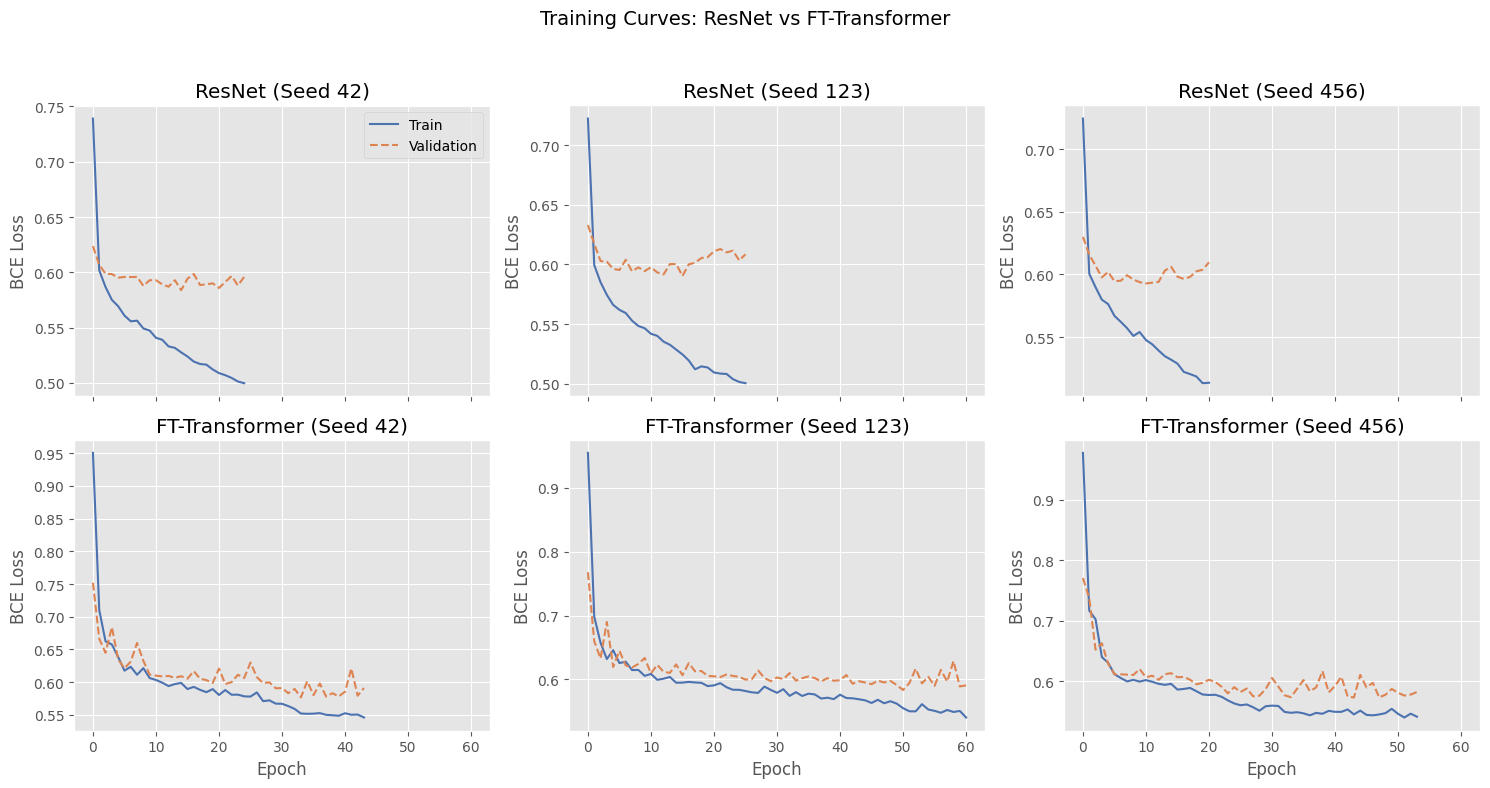

In [46]:
# Training Curves: ResNet vs FT-Transformer

n_seeds = len(SEEDS)

color_train = "#4C72B0"   # blue
color_val   = "#DD8452"   # orange

plt.style.use("ggplot")

fig, axes = plt.subplots(2, n_seeds, figsize=(5 * n_seeds, 8), sharex=True)

# Ensure axes shape is consistent
if n_seeds == 1:
    axes = axes.reshape(2, 1)

# ResNet (top row)
for i, seed in enumerate(SEEDS):
    ax = axes[0, i]

    if seed in resnet_train_curves:
        tr_l, va_l = resnet_train_curves[seed]

        ax.plot(tr_l, label="Train", color=color_train, linewidth=1.5)
        ax.plot(va_l, label="Validation", color=color_val, linestyle="--", linewidth=1.5)

    ax.set_title(f"ResNet (Seed {seed})")
    ax.set_ylabel("BCE Loss")

# FT-Transformer (bottom row)
for i, seed in enumerate(SEEDS):
    ax = axes[1, i]

    if seed in ft_train_curves:
        tr_l, va_l = ft_train_curves[seed]

        ax.plot(tr_l, label="Train", color=color_train, linewidth=1.5)
        ax.plot(va_l, label="Validation", color=color_val, linestyle="--", linewidth=1.5)

    ax.set_title(f"FT-Transformer (Seed {seed})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCE Loss")

# Single legend (top-left plot)
axes[0, 0].legend(loc="upper right")

# Final layout
fig.suptitle("Training Curves: ResNet vs FT-Transformer", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

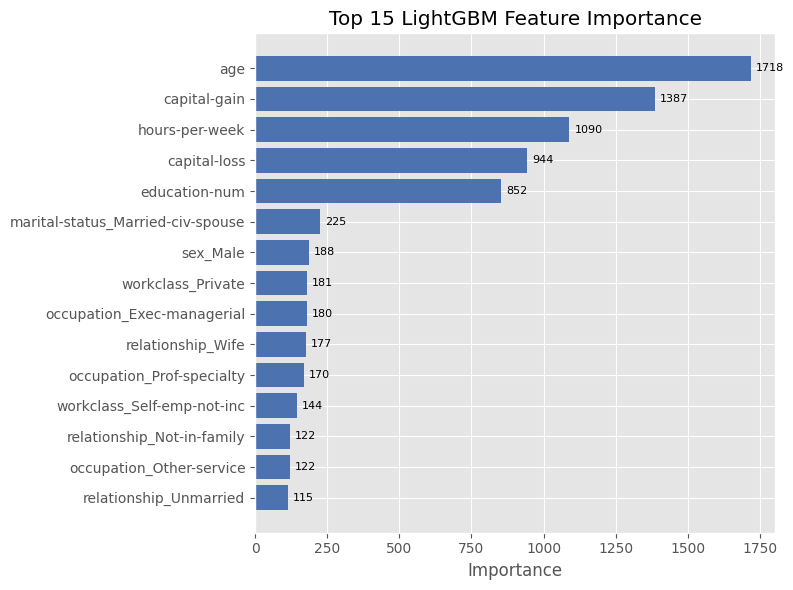

In [47]:
# Top 15 LightGBM Feature Importance

if "lgb_model_best" in globals() and lgb_model_best is not None:

    # Build feature importance DataFrame
    fi_df = pd.DataFrame({
        "feature": X_train_c.columns,
        "importance": lgb_model_best.feature_importances_,
    })

    # Top 15 features
    fi_df = (
        fi_df.sort_values("importance", ascending=False)
        .head(15)
        .sort_values("importance", ascending=True)
    )

    color_bar = "#4C72B0"

    plt.style.use("ggplot")
    fig, ax = plt.subplots(figsize=(8, 6))

    bars = ax.barh(fi_df["feature"], fi_df["importance"], color=color_bar)

    # Add value labels (with slight offset)
    max_val = fi_df["importance"].max()
    offset = 0.01 * max_val

    for i, v in enumerate(fi_df["importance"]):
        ax.text(v + offset, i, f"{v:.0f}", va="center", fontsize=8)

    ax.set_title("Top 15 LightGBM Feature Importance")
    ax.set_xlabel("Importance")
    ax.set_ylabel("")

    plt.tight_layout()
    plt.show()

In [48]:
# Get best LightGBM seed based on AUC
lgb_results = [r for r in all_results if r["method"] == "LightGBM"]

best_seed = max(lgb_results, key=lambda x: x["auc"])["seed"]

print("Best LightGBM seed based on AUC:", best_seed)

# Re-train best model
set_seed(best_seed)

lgb_model_best = lgb.LGBMClassifier(
    **best_lgb,
    objective="binary",
    metric="auc",
    random_state=best_seed,
    verbosity=-1,
    n_jobs=-1
)

lgb_model_best.fit(X_train_c, y_train_np)

Best LightGBM seed based on AUC: 42


,boosting_type,'gbdt'
,num_leaves,21
,max_depth,-1
,learning_rate,0.0262209763647716
,n_estimators,499
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,34


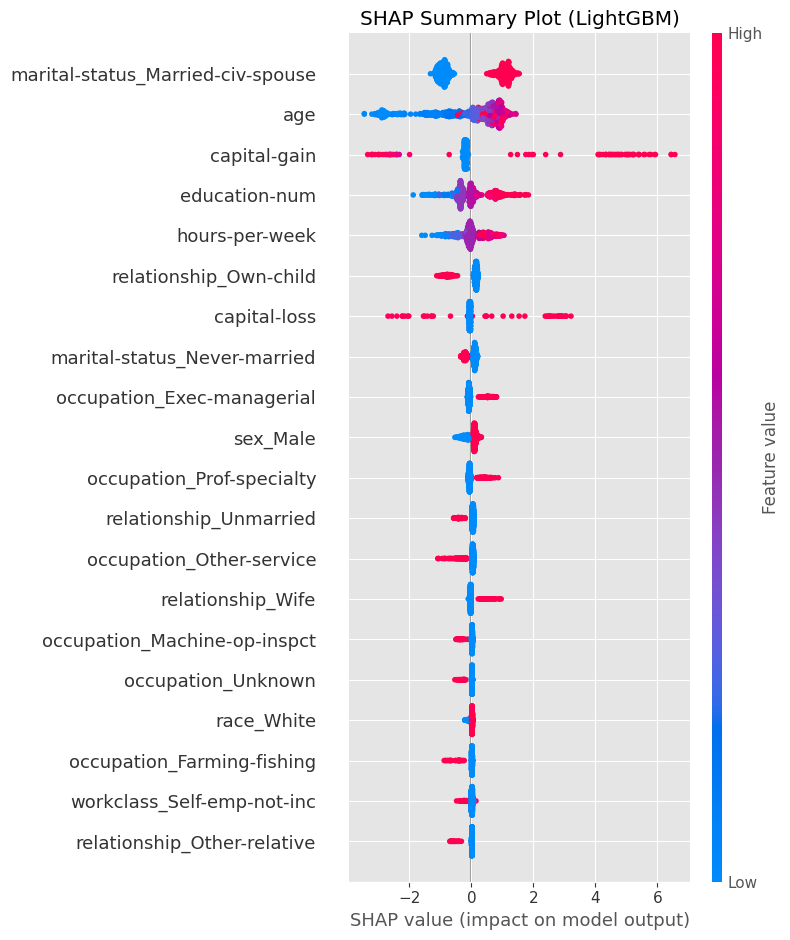

In [49]:
# SHAP Summary Plot (LightGBM)

import shap

# Sample for speed
X_shap = X_test_c.sample(min(1000, len(X_test_c)), random_state=42)

# Explainer
explainer = shap.TreeExplainer(lgb_model_best)

# SHAP values
shap_values = explainer.shap_values(X_shap)

# Handle different SHAP outputs
if isinstance(shap_values, list):
    # Older SHAP binary-classification output
    shap_to_plot = shap_values[1]
elif hasattr(shap_values, "values"):
    # Newer Explanation object
    shap_to_plot = shap_values.values
else:
    shap_to_plot = shap_values

# Plot
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_to_plot, X_shap, show=False)

plt.title("SHAP Summary Plot (LightGBM)")
plt.tight_layout()
plt.show()

## Analysis & Conclusions

### Summary
We compared six methods on the UCI Adult Income binary classification task.

- **LightGBM** and **XGBoost** typically achieve top AUC-ROC on this dataset
  thanks to their ability to handle mixed numerical/categorical features.
- **FT-Transformer** leverages embeddings for categorical features, which can
  yield competitive AUC with sufficient training.
- **Logistic Regression** provides a fast and interpretable baseline.
- **ResNet** and **Random Forest** round out the comparison.

### Observations
- The dataset is moderately imbalanced (~24% positive); AUC-ROC is the most
  reliable metric here.
- OrdinalEncoding + StandardScaling is a straightforward preprocessing pipeline
  that works across all methods.
- 3-seed evaluation reveals model stability under random initialization.

### Next Steps
- One-hot encoding for tree methods vs. ordinal for neural methods. /
- Class-weight adjustment to improve F1 for the minority class.
- SHAP explanations for the best-performing model. /
